In [89]:
import re

import pandas
import pandas as pd
from PIL.Image import Image
from PIL.ImageFile import ImageFile
from pandas import DataFrame

from Dataloaders import AnimalDataloader


def strip_numbers(string):
    return re.sub(r'_[0-9]*$', '',string)

data = pandas.read_csv('data/annotations/list.txt', sep=" ")
print((data.count()))
data["Image"] = data["Image"].apply(lambda x: strip_numbers(x))
unique_df = DataFrame(pd.unique(data["Image"]))
print(unique_df)

Image       7349
CLASS-ID    7349
SPECIES     7349
BREED_ID    7349
dtype: int64
                             0
0                   Abyssinian
1             american_bulldog
2    american_pit_bull_terrier
3                 basset_hound
4                       beagle
5                       Bengal
6                       Birman
7                       Bombay
8                        boxer
9            British_Shorthair
10                   chihuahua
11                Egyptian_Mau
12      english_cocker_spaniel
13              english_setter
14          german_shorthaired
15              great_pyrenees
16                    havanese
17               japanese_chin
18                    keeshond
19                  leonberger
20                  Maine_Coon
21          miniature_pinscher
22                newfoundland
23                     Persian
24                  pomeranian
25                         pug
26                     Ragdoll
27                Russian_Blue
28               sai

In [1]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from PIL import Image
img = Image.open('data/images/Persian_12.jpg')
img.show()


In [12]:
from training import load_data

data_df = load_data()


            image  label
0  Abyssinian_100      0
1  Abyssinian_101      0
2  Abyssinian_102      0
3  Abyssinian_103      0
4  Abyssinian_104      0


             width       height  aspect_ratio
count  7349.000000  7349.000000   7349.000000
mean    437.237447   391.387264      1.172173
std     115.775876   109.394560      0.329474
min     114.000000   103.000000      0.420000
25%     337.000000   333.000000      0.750000
50%     500.000000   375.000000      1.333333
75%     500.000000   500.000000      1.492537
max    3264.000000  2606.000000      2.564103


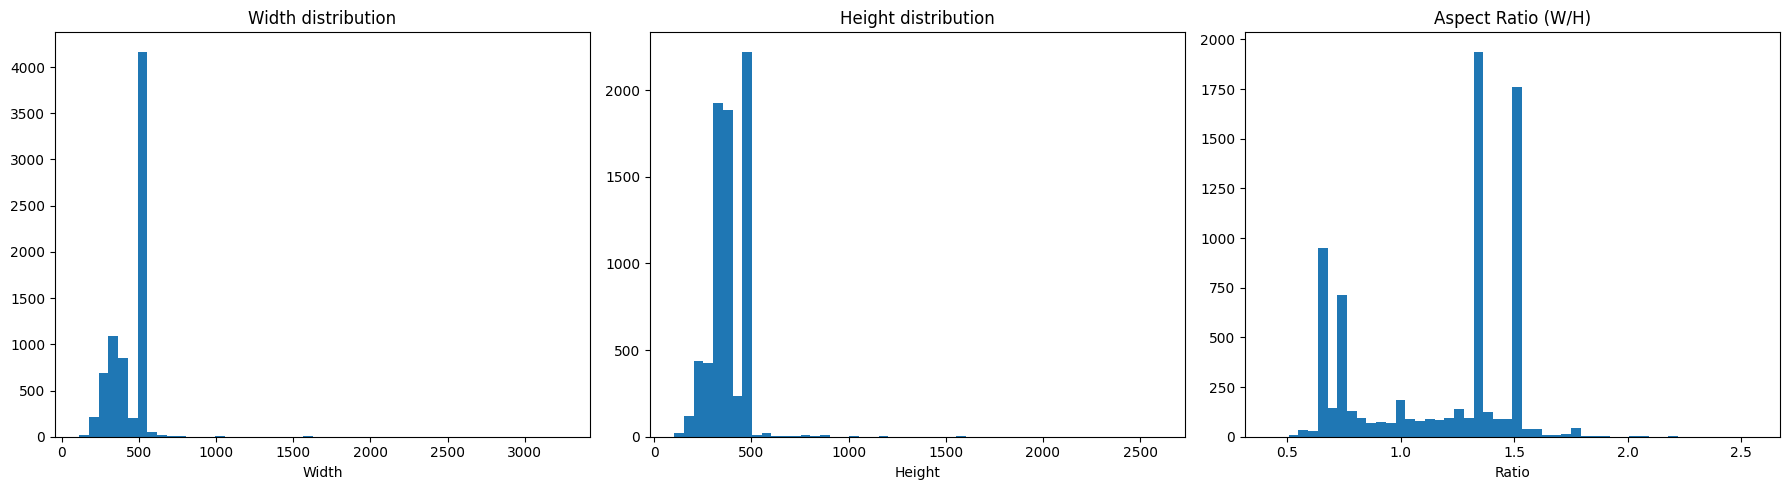

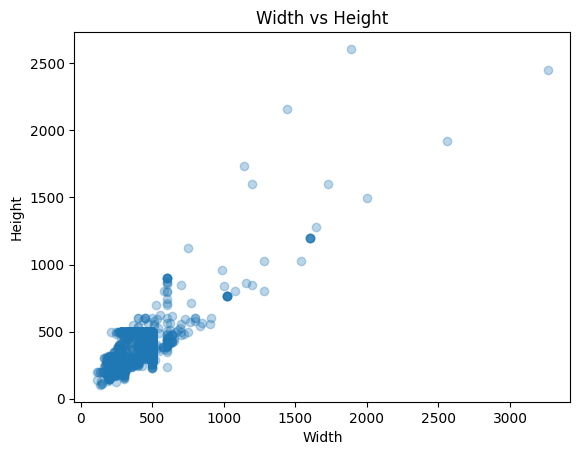

In [13]:

import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

IMG_DIR = r"data/images/"  
DF = data_df             

widths = []
heights = []

for base in DF["image"]:
    path = os.path.join(IMG_DIR, f"{base}.jpg")

    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        print(f"Error with {path}: {e}")

shapes_df = pd.DataFrame({
    "width": widths,
    "height": heights
})

shapes_df["aspect_ratio"] = shapes_df["width"] / shapes_df["height"]

print(shapes_df.describe())

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(shapes_df["width"], bins=50)
plt.title("Width distribution")
plt.xlabel("Width")

plt.subplot(1, 3, 2)
plt.hist(shapes_df["height"], bins=50)
plt.title("Height distribution")
plt.xlabel("Height")

plt.subplot(1, 3, 3)
plt.hist(shapes_df["aspect_ratio"], bins=50)
plt.title("Aspect Ratio (W/H)")
plt.xlabel("Ratio")

plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(shapes_df["width"], shapes_df["height"], alpha=0.3)
plt.title("Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()
